In [1]:
#C:\Users\ls2236\AppData\Local\anaconda3\envs\arco\python.exe C:\Users\ls2236\Projects\BIG\ERA5\arco-era5\download\download_temperature.py
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from distributed import Client,LocalCluster
import time
from scipy import ndimage
import matplotlib.colors
import os
from matplotlib.colors import TwoSlopeNorm
import datetime
import math

In [2]:
dir_data = r"C:\Users\ls2236\Projects\cao_tracker\data\statistics_and_transformed"
dir_out = r"C:\Users\ls2236\Projects\cao_tracker\results\tracker_daily_stats"
save_path = r"C:\Users\ls2236\Projects\cao_tracker\results\tracker_daily_stats\img"

In [3]:
anomaly = xr.open_dataset(os.path.join(dir_data, 'Rolling_daily_anomaly.nc'))
standard_anomaly = xr.open_dataset(os.path.join(dir_data, 'Rolling_daily_standard_anomaly.nc'))
anomaly = anomaly["daily_t2_min"]
standard_anomaly = standard_anomaly["daily_t2_min"]

In [4]:
tmean_season_std = xr.open_dataset(os.path.join(dir_data, 'Seasonal_daily_stdev.nc'))


In [10]:
standard_anomaly


<xarray.DataArray 'daily_t2_min' (time: 30316, latitude: 281, longitude: 441)> Size: 30GB
[3756789036 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float32 1kB 90.0 89.75 89.5 89.25 ... 20.5 20.25 20.0
  * longitude  (longitude) float32 2kB -150.0 -149.8 -149.5 ... -40.25 -40.0
  * time       (time) datetime64[ns] 243kB 1940-01-01 1940-01-02 ... 2022-12-31
    dayofyear  (time) int64 243kB ...

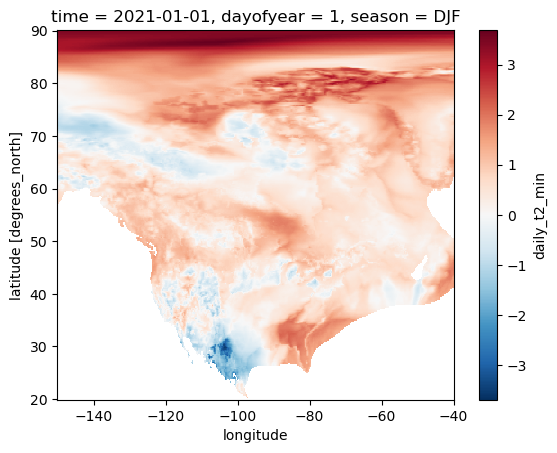

In [12]:
standard_anomaly.sel(time='2021-01-01').where(tmean_season_std["daily_t2_min"].sel(season='DJF') > 3).plot()

In [35]:
year=1943

In [193]:
date_i = '1943-01-16'
date_f = '1943-01-25'

data_array_stdev = standard_anomaly.sel(time=slice(date_i,date_f))
data_array_anom = anomaly.sel(time=slice(date_i,date_f))

#cao_bool = data_array_stdev.where(data_array_stdev > 2,0)
cao_bool = data_array_stdev < -1.5
data_array = cao_bool.sel(time=slice(date_i,date_f))

time = data_array["time"].values
latitude = data_array["latitude"].values
longitude = data_array["longitude"].values
data = np.random.randint(0, 2, size=(len(time), len(latitude), len(longitude)))

0
1
2
3
4
5
6


IndexError: index 6 is out of bounds for axis 0 with size 6

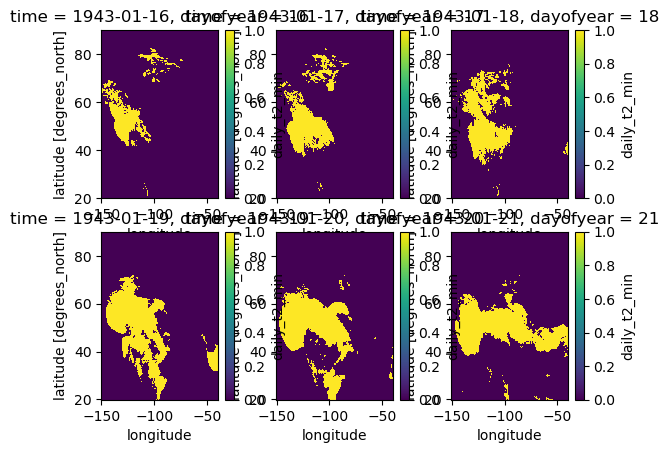

In [194]:
#data_array[2].plot()

fig, axes = plt.subplots(nrows=2, ncols=3)
axes = axes.flatten()
for i in np.arange(0,(np.size(data_array)-1)):
    print(i)
    p=data_array[i].plot(ax=axes[i])

#plt.savefig(os.path.join(save_path, 'temp_stdev.png'))
plt.show()

0
1
2
3
4
5
6


IndexError: index 6 is out of bounds for axis 0 with size 6

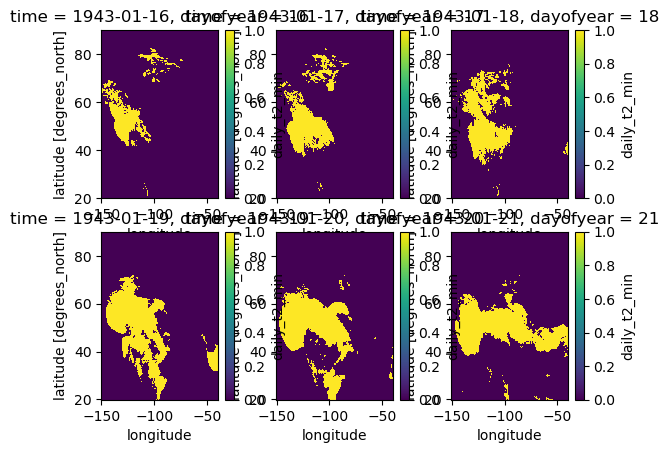

In [195]:
#data_array[2].plot()

fig, axes = plt.subplots(nrows=2, ncols=3)
axes = axes.flatten()
for i in np.arange(0,(np.size(data_array)-1)):
    print(i)
    p=data_array[i].plot(ax=axes[i])

#plt.savefig(os.path.join(save_path, 'temp_stdev.png'))
plt.show()

In [196]:
t_idx=4
t_idx

4

In [197]:
time_slice = data_array.isel(time=t_idx)
anom_slice = data_array_anom.isel(time=t_idx)
stdev_slice = data_array_stdev.isel(time=t_idx)

In [198]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["purple","darkblue","blue","lightblue","white","lightcoral","red","darkred","pink"])
z = [-35,-30,-25,-20,-15,-10,-5,0,1,10,20,50]
norm = TwoSlopeNorm(vmin=np.min(z), vcenter=0, vmax=np.max(z))



In [191]:
size_threshold=1750

   index              anomaly  labs  Nsize
0      0  -20.275741577148438    15  18497


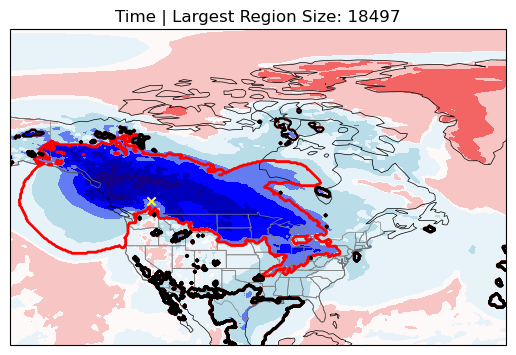

In [199]:
labeled_slice, num_features = ndimage.label(time_slice.values)
region_sizes = np.bincount(labeled_slice.ravel())
region_sizes[0] = 0  # Ignore background
largest_region_label = np.argwhere(region_sizes >= size_threshold)

if np.size(largest_region_label) > 0:
    largest_region_size = region_sizes[largest_region_label]
    if len(region_sizes) > 1:
        lab_list = []
        for lab in largest_region_label:
            lab_list.append([anom_slice.where(labeled_slice == lab).quantile(0.25).values])
        loc = lab_list <= lab_list[np.argmax(region_sizes[largest_region_label])]+(region_sizes[largest_region_label] - np.max(region_sizes[largest_region_label]))/5000
        region_info = pd.DataFrame(lab_list,columns=["anomaly"])
        region_info['labs'] = largest_region_label
        region_info['Nsize'] = region_sizes[largest_region_label]
        region_info =region_info.loc[loc]
        region_info=region_info.reset_index()
        print(region_info)
        largest_region_label = region_info['labs'][region_info["anomaly"].argmin()]
        #largest_region_label = largest_region_label[np.argmin(lab_list)]
        largest_region_size = region_sizes[largest_region_label]

temp_array = xr.DataArray(labeled_slice,coords={"latitude": time_slice["latitude"].values,"longitude": time_slice["longitude"].values},dims=['latitude','longitude'])
temp_array = xr.DataArray(labeled_slice,coords={"latitude": time_slice["latitude"].values,"longitude": time_slice["longitude"].values},dims=['latitude','longitude'])
temp2=stdev_slice.where(labeled_slice == largest_region_label,0)
anom_min=anom_slice.where(labeled_slice == largest_region_label,0).min().values
anom_mean=anom_slice.where(labeled_slice == largest_region_label,0).mean().values
anom_min_all=anom_slice.min().values
com = ndimage.center_of_mass(temp2.values)
com_lat = lat_vals[int(com[0])]
com_lon = lon_vals[int(com[1])]

lat_vals = latitude
lon_vals = longitude

ax = plt.axes(projection=ccrs.PlateCarree())
plt.contourf(lon_vals, lat_vals, anom_slice,cmap=cmap,norm=norm,levels=z,extend="both")
plt.contour(lon_vals, lat_vals, temp_array,colors="red")
plt.contour(lon_vals, lat_vals, temp_array.where(labeled_slice != largest_region_label),colors="black")
plt.scatter(com_lon, com_lat, color='yellow', marker='x', label='Center of Mass')
ax.coastlines( edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
plt.title(f'Time | Largest Region Size: {largest_region_size}')
plt.show()

In [83]:
PARAMETERS = {
    #"dirname": r"C:\Users\ls2236\Projects\BIG\ERA5\arco-era5\data\tables",
    "dirname": r"C:\Users\ls2236\Projects\cao_tracker\results\tracker_daily_stats\tables",
    "distance": 3500,
    "lat_diff_max": 3,
    "output_file": r"C:\Users\ls2236\Projects\cao_tracker\results\tracker_daily_stats\cao_tracker_rolling_1_5_stdev.csv"
    #"output_file": r"C:\Users\ls2236\Projects\BIG\ERA5\arco-era5\data\cao_tracker_result.csv"
}

In [84]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

In [85]:
dirname = r"C:\Users\ls2236\Projects\cao_tracker\results\tracker_daily_stats\tables"
filenames=os.listdir(dirname)
dfs = list()
for f in filenames:
    data = pd.read_csv(os.path.join(dirname,f),sep=";")
    # .stem is method for pathlib objects to get the filename w/o the extension
    data['file'] = f
    dfs.append(data)

df = pd.concat(dfs, ignore_index=True)


In [ ]:
df["file"] = df["file"].str.replace(".csv", " ")
df['time'] = pd.to_datetime(df['time'])

df = df.dropna(subset=['lat'])
df['ddiff'] = df['time'].diff().dt.days
df = df.reset_index(drop=True)
df.loc[0,'ddiff']=1

df['group'] = (df['ddiff'] != 1).cumsum()
df.loc[0,'group']=0

df['group'] = df['group']+1


group_counts = df['group'].value_counts()

df = df[df['group'].isin(group_counts[group_counts > 1].index)]

df = df.reset_index(drop=True)

df['ndays']=df.groupby('group')["group"].transform('count')


# Update group based on distance
df['distance'] = np.nan
for i in range(1, len(df)):
    # Calculate the distance to the previous row
    distance = haversine(df['lat'].iloc[i], df['lon'].iloc[i],
                        df['lat'].iloc[i-1], df['lon'].iloc[i-1])
    df.loc[i,'distance'] = distance
df.loc[0,'distance']=0

#df[df['distance']>1000]
df['group_diff']=df['group'] - df['group'].shift()
df['group_diff'][0]=0
df['distance'][df['group_diff']!=0]=0


increments = df.groupby('group')['distance'].transform(lambda x: (x >PARAMETERS["distance"] ).astype(int))
df['increments'] = increments
df['increments_sum'] = increments.cumsum()
df['new_group'] = df['group'] + df['increments_sum'] 


filtered_df = df.groupby('new_group').filter(lambda x: len(x) > 1)
filtered_df = filtered_df.reset_index(drop=True)


# Drop the specified columns
filtered_df = filtered_df.drop(columns=['group', 'group_diff', 'increments', 'increments_sum'])

# Rename the 'new_group' column to 'cao_group'
filtered_df = filtered_df.rename(columns={'new_group': 'cao_group'})


group = filtered_df['cao_group'] - filtered_df['cao_group'].shift()
group[0]=0
filtered_df['pre_group'] = group
filtered_df['new_group'] = np.ones(np.size(filtered_df['cao_group']))
filtered_df['new_group'][filtered_df['pre_group']==0]=0
filtered_df['cao_group'] = filtered_df['new_group'].cumsum()


filtered_df = filtered_df.drop(columns=['pre_group', 'new_group'])

#lattiude filter
group = filtered_df['lat'] - filtered_df['lat'].shift()
group[0]=0
filtered_df['lat_diff'] = group


filtered_df['new_group_lat'] = np.zeros(np.size(filtered_df['lat']))
increments = filtered_df.groupby('cao_group')['lat_diff'].transform(lambda x: (x > PARAMETERS["lat_diff_max"]).astype(int))
filtered_df['increments_lat'] = increments
filtered_df['increments_sum_lat'] = increments.cumsum()
filtered_df['new_group'] = filtered_df['cao_group'] + filtered_df['increments_sum_lat'] 
filtered_df2 = filtered_df.groupby('new_group').filter(lambda x: len(x) > 1)
filtered_df2 = filtered_df2.reset_index(drop=True)


group = filtered_df2['new_group'] - filtered_df2['new_group'].shift()
group[0]=0
filtered_df2['pre_group'] = group
filtered_df2['new_group'] = np.ones(np.size(filtered_df2['new_group']))
filtered_df2['new_group'][filtered_df2['pre_group']==0]=0
filtered_df2['cao_group'] = filtered_df2['new_group'].cumsum()


filtered_df2['ndays']=filtered_df2.groupby('cao_group')["cao_group"].transform('count')


filtered_df2 = filtered_df2.drop(columns=['ddiff', 'lat_diff','new_group_lat','increments_lat','increments_sum_lat','new_group','pre_group'])

filtered_df2.to_csv(PARAMETERS["output_file"],sep=';',index=False)

In [176]:
date_i='1943-01-16'
date_f='1943-01-25'

In [177]:
df = filtered_df2
cond1 = df["time"] >= date_i
cond2 = df["time"] <= date_f
df_sel=df[cond1&cond2]

In [178]:
df_sel

,time,lat,lon,min_rel,min_all,anom_mean,size,file,ndays,distance,cao_group
127,1943-01-16,53.25,-128.25,-23.322189,-23.322189,-0.600980,6358.0,1943,10,0.000000,35.0
128,1943-01-17,49.50,-121.75,-30.285690,-30.285690,-1.036821,9957.0,1943,10,613.902692,35.0
129,1943-01-18,51.75,-119.25,-27.284775,-27.284775,-1.530576,13632.0,1943,10,306.055649,35.0
130,1943-01-19,50.75,-117.50,-29.973938,-29.973938,-2.356033,20165.0,1943,10,164.913653,35.0
131,1943-01-20,52.00,-118.75,-30.895050,-30.895050,-2.267123,18497.0,1943,10,163.844800,35.0
132,1943-01-21,50.25,-105.00,-30.507324,-30.507324,-2.159386,21534.0,1943,10,977.548151,35.0
133,1943-01-22,50.25,-118.75,-28.232758,-28.232758,-1.346108,14441.0,1943,10,976.268165,35.0
134,1943-01-23,51.25,-126.75,-30.099396,-30.099396,-1.181878,12474.0,1943,10,573.400268,35.0
135,1943-01-24,54.25,-121.00,-26.691269,-26.691269,-1.101534,8026.0,1943,10,510.648681,35.0
136,1943-01-25,54.50,-126.00,-25.027573,-25.027573,-0.420668,3459.0,1943,10,324.964348,35.0


C:\Users\ls2236\AppData\Local\Temp\ipykernel_6196\1199230604.py:7: FutureWarning: The provided callable <built-in function min> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  datei, datef = df_sel['time'].agg([min, max])
C:\Users\ls2236\AppData\Local\Temp\ipykernel_6196\1199230604.py:7: FutureWarning: The provided callable <built-in function max> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  datei, datef = df_sel['time'].agg([min, max])


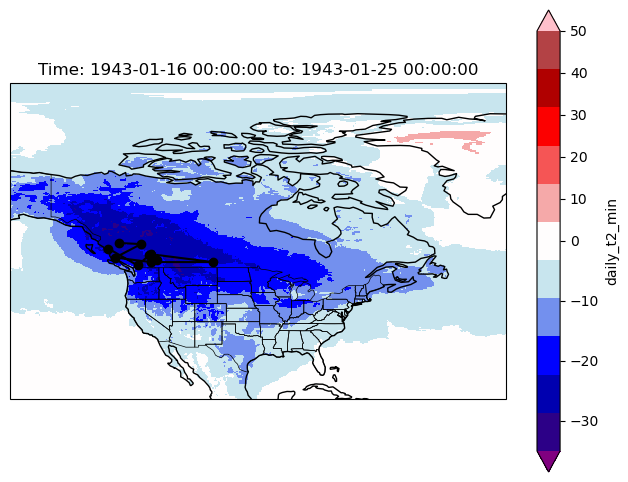

In [179]:
save_path = "results/experiment_1_5_stdev_rolling/img/"
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["purple","darkblue","blue","lightblue","white","lightcoral","red","darkred","pink"])
z = [-35,-30,-25,-20,-15,-10,-5,0,1,10,20,50]
norm = TwoSlopeNorm(vmin=np.min(z), vcenter=0, vmax=np.max(z))


datei, datef = df_sel['time'].agg([min, max])
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
anomaly.sel(time=slice(datei,datef)).min("time").plot(cmap=cmap,norm=norm,levels=z,extend="both")
plt.plot(df_sel['lon'],df_sel['lat'],'-o',color="black")
plt.title(f'Time: {str(datei)} to: {datef}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
ax.coastlines()
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
plt.show()